# Isogrid Module Calculator
Supports both regular isogrid and open web calculations.
Does not optimize

### Definitions from Handbook for translating equations
t = thickness of Skin  
b = width of rib web  
d = depth of web  
c = depth of flange  
w = width of flange  
s = t+d = plate thickness of unflanged isogrid  
h = height of triangle  
a = leg of triangle (center to center of nodes)  
kc = column fixity

beta = b/a  (width of rib web/leg of triangle)  

[6, 0.02, 0.035, 0.025, 18, 'Optimized LW']
Tbar 0.022
General Instability - 763.2 lbf/in  14506 lbf
Skin Buckling       - 762.2 lbf/in  14486 lbf
Rib Cripling        - 65461.5 lbf/in 1244203 lbf
Rel Weight: 0.836
Rel Strength: 1.86
[6, 0.02, 0.063, 0.025, 24, 'Optimized HW']
Tbar 0.026
General Instability - 1420.5 lbf/in  26999 lbf
Skin Buckling       - 1430.5 lbf/in  27188 lbf
Rib Cripling        - 21329.5 lbf/in 405402 lbf
Rel Weight: 0.965
Rel Strength: 3.47
[6, 0.04, 0.16, 0.04, 18, 'Current']
Tbar 0.058
General Instability - 8155.7 lbf/in 155782 lbf
Skin Buckling       - 6671.3 lbf/in 127428 lbf
Rib Cripling        - 17722.0 lbf/in 338506 lbf
Rel Weight: 2.18
Rel Strength: 16.4
[6, 0.0, 0.234, 0.04, 18, 'Open Web Current']
Tbar 0.026
General Instability - 11518.9 lbf/in 220022 lbf
Rib Cripling        - 231.5 lbf/in   4422 lbf
Rel Weight: 1.59
Rel Strength: 0.568
[6, 0.0, 0.234, 0.05, 18, 'Open Web wider ribs']
Tbar 0.033
General Instability - 14304.4 lbf/in 274125 lbf
Rib Criplin

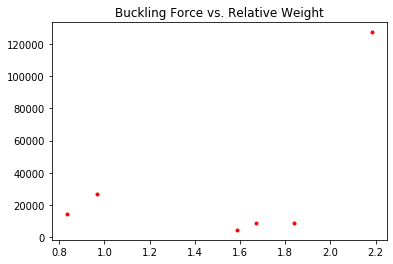

In [21]:
import math
import matplotlib.pyplot as plt

# Material properties 
E = 69.0 # Young's Modules, GPa for Al 6061-T6
E_imp = 10000*1000 # PSI
nu = 0.33 # Poisson's Ratio for Al 6061-T6
material_name = '6061-T6'
F_ty = 40 # ksi (Yield Strength)
F_tu = 45 # ksi (Ultimate Strength)

# Instability Coefs
c0 = 0.397    # 4.2.005
c1 = 10.2     # 4.2.006
c2 = 0.616    # 4.2.008

kc = 2.0 # assumed on page 4.9.009

# Common Properties
flanges = False

# Parametric Space
# Inner Diameter, wall_t, rib_depth, rib_width, num_cells, Name
module_options = [[6,0.02,0.035,0.025,18, 'Optimized LW'],
                  [6,0.02,0.063,0.025,24, 'Optimized HW'],
                  [6,0.04,0.16,0.04,18, 'Current'], 
                  [6,0.00,0.234,0.04,18, 'Open Web Current'],
                  [6,0.00,0.234,0.05,18, 'Open Web wider ribs'],
                  [6,0.00,0.190,0.04,24, 'Open Web 24 cells']]
results = []
for module in module_options:
    print(module)
    module_id = module[0]
    skin_t = module[1]
    rib_depth = module[2]
    rib_t = module[3]
    num_radial_divisions = module[4]
    module_od = module_id+2*rib_t
    module_r = module_od/2
    rel_weight_data = []
    pattern_size = module_od*math.pi/num_radial_divisions
    cell_height = pattern_size
    a = 2*cell_height/(3**0.5)


    if skin_t == 0.0:
        # Open Web
        t_bar = 3*rib_t*rib_depth/cell_height
        beta = rib_t/a
        N_cr_1 = c0*E_imp*(rib_t*rib_depth)/(module_r*cell_height) # Eqn 4.9.8 (Rectangular Stiffeners)
        N_cr_2 = 1.422*kc*E_imp*rib_depth*(beta**3) # Eqn 4.9.10
        
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2)
    
        print(f'Tbar {t_bar:.3f}')
        print('General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
    else:
        # Closed Web
        alpha = (rib_t*rib_depth)/(skin_t*cell_height) # Web non-dimensional ratio, pg. 2.0.008
        delta = rib_depth/skin_t # rib depth to skin thickness ratio, pg. 2.0.008
        if flanges == False:
            beta = (3*alpha*(1+delta)**2+(1+alpha)*(1+alpha*delta**2))**0.5
            t_star = skin_t*beta/(1+alpha) # equivilent thickness, Eq. 2.5.3
            t_bar = skin_t*(1+3*alpha)
            E_star = E*(1+alpha)**2.0/beta # equivilent Young's Modulus Eq. 2.5.4#
        N_cr_1 = c0*E_imp*skin_t*skin_t/module_r*beta
        N_cr_2 = c1*E_imp*skin_t*(1+alpha)*(skin_t*skin_t)/(pattern_size*pattern_size)
        N_cr_3 = c2*E_imp*skin_t*(1+alpha)*(rib_t*rib_t)/(rib_depth*rib_depth)
    
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        F_cr_3 = N_cr_3*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2,F_cr_3)
    
        print(f'Tbar {t_bar:.3f}')
        print('General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('Skin Buckling       - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
        print('Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_3,F_cr_3))
            
    cs_area = t_bar*2*math.pi*(module_r+t_bar/2)
    if skin_t == 0.0:
        # Note: We add the weight of skin to the weight
        cs_area = (t_bar+0.016)*2*math.pi*(module_r+t_bar/2)
    rel_w = cs_area/0.513412
    print('Rel Weight: {:4.3}'.format(rel_w))
    print('Rel Strength: {:4.3}'.format(strength/7783))
    rel_weight_data.append(rel_w)
    results.append([module_id, rel_w, strength])

# Buckling
buckling_plot = plt.figure(1)
plt.title('Buckling Force vs. Relative Weight')
for item in results:
    plt.plot(item[1], item[2], 'r.', label='id_'+str(item[0]))
#plt.legend()

